# Restaurant Data Analysis

## Load the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

In [2]:
df = pd.read_csv("/content/Dataset .csv")
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


## Initial Dataset Understanding

In [3]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0
Cuisines,9


## Clean Column Names

In [4]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.columns

Index(['restaurant_id', 'restaurant_name', 'country_code', 'city', 'address',
       'locality', 'locality_verbose', 'longitude', 'latitude', 'cuisines',
       'average_cost_for_two', 'currency', 'has_table_booking',
       'has_online_delivery', 'is_delivering_now', 'switch_to_order_menu',
       'price_range', 'aggregate_rating', 'rating_color', 'rating_text',
       'votes'],
      dtype='object')

## Cleaning Country Info

In [5]:
country_map = {
    1: "India",
    14: "Australia",
    30: "Brazil",
    37: "Canada",
    94: "Indonesia",
    148: "New Zealand",
    162: "Philippines",
    166: "Qatar",
    184: "Singapore",
    189: "South Africa",
    191: "Sri Lanka",
    208: "Turkey",
    214: "UAE",
    215: "United Kingdom",
    216: "United States"
}

df["country"] = df["country_code"].map(country_map)

##  Modify The Column Data

In [6]:
df["has_online_delivery"] = df["has_online_delivery"].map({"Yes": 1, "No": 0})
df["has_table_booking"] = df["has_table_booking"].map({"Yes": 1, "No": 0})


df["cuisines"] = df["cuisines"].str.strip()
df["cuisine_list"] = df["cuisines"].str.split(", ")

## Top Cuisines

In [7]:
all_cuisines = df.explode("cuisine_list")
top_cuisines = all_cuisines["cuisine_list"].value_counts().head(3)
top_cuisines

top_cuisine_percent = (top_cuisines / df.shape[0]) * 100
top_cuisine_percent

,count
cuisine_list,
North Indian,41.461627
Chinese,28.635745
Fast Food,20.793634


## City Analysis

In [9]:
top_city = df["city"].value_counts().idxmax()
top_city

city_avg_rating = df.groupby("city")["aggregate_rating"].mean().sort_values(ascending=False)
city_avg_rating.head()

highest_rated_city = city_avg_rating.idxmax()
highest_rated_city

'Inner City'

## Price Range Distribution

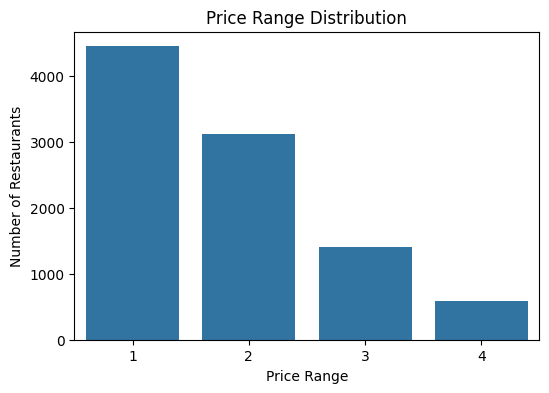

,count
price_range,
1,46.529159
2,32.593446
3,14.741912
4,6.135483


In [10]:
price_dist = df["price_range"].value_counts().sort_index()

plt.figure(figsize=(6,4))
sns.barplot(x=price_dist.index, y=price_dist.values)
plt.title("Price Range Distribution")
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")
plt.show()

(price_dist / df.shape[0]) * 100

## Online Delivery

In [11]:
online_delivery_percent = df["has_online_delivery"].value_counts(normalize=True) * 100
online_delivery_percent

df.groupby("has_online_delivery")["aggregate_rating"].mean()

,aggregate_rating
has_online_delivery,
0,2.465296
1,3.248837


## Restaurant Ratings

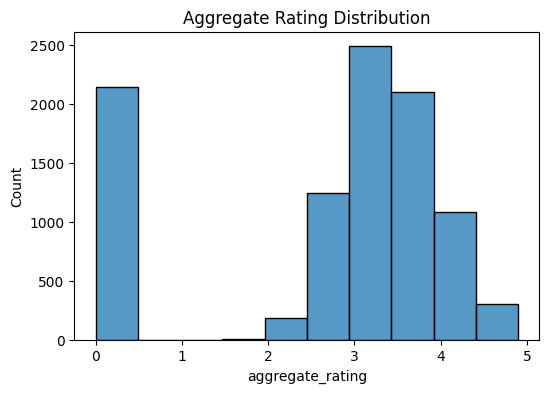

np.float64(156.909747670401)

In [12]:
plt.figure(figsize=(6,4))
sns.histplot(df["aggregate_rating"], bins=10)
plt.title("Aggregate Rating Distribution")
plt.show()

df["aggregate_rating"].round().value_counts().idxmax()
df["votes"].mean()

## Cuisine Combination

In [13]:
cuisine_combo = df["cuisines"].value_counts().head(10)
cuisine_combo
df.groupby("cuisines")["aggregate_rating"].mean().sort_values(ascending=False).head(10)

,aggregate_rating
cuisines,
"Burger, Bar Food, Steak",4.9
"American, Burger, Grill",4.9
"American, Caribbean, Seafood",4.9
"American, Coffee and Tea",4.9
"Mexican, American, Healthy Food",4.9
"Italian, Bakery, Continental",4.9
"BBQ, Breakfast, Southern",4.9
"European, German",4.9
"Hawaiian, Seafood",4.9


## Geographic Analysis

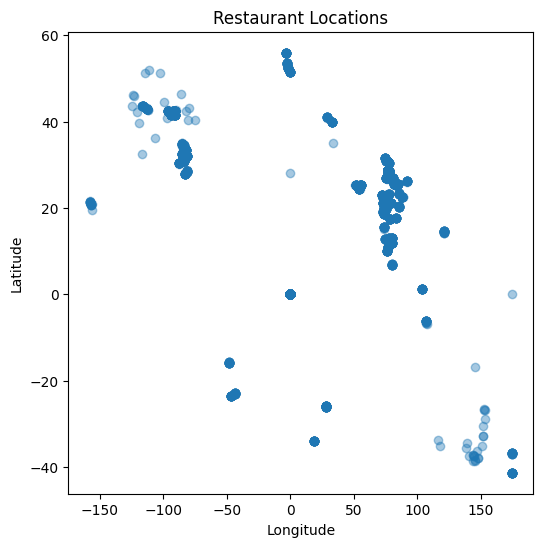

In [14]:
plt.figure(figsize=(6,6))
plt.scatter(df["longitude"], df["latitude"], alpha=0.4)
plt.title("Restaurant Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

## Restaurant Chains

In [15]:
chain_data = df["restaurant_name"].value_counts()
chains = chain_data[chain_data > 1]
chains.head()

df[df["restaurant_name"].isin(chains.index)] \
.groupby("restaurant_name")[["aggregate_rating", "votes"]] \
.mean().sort_values("votes", ascending=False).head()

,aggregate_rating,votes
restaurant_name,,
Truffles,3.950000,4841.000000
Joey's Pizza,4.250000,3903.500000
AB's - Absolute Barbecues,4.825000,3350.000000
Big Chill,4.475000,2713.250000
Big Yellow Door,4.266667,2503.666667


##  Restaurant Reviews

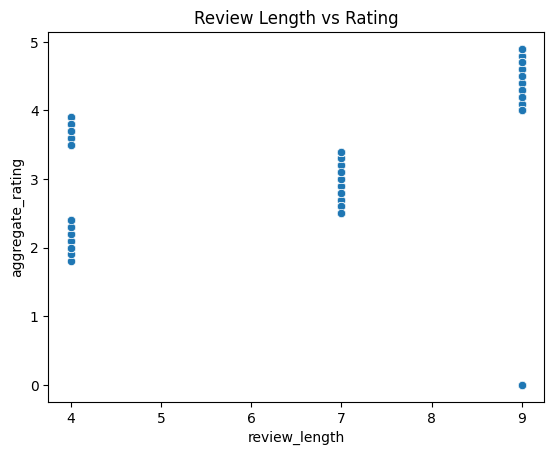

In [16]:
df["review_length"] = df["rating_text"].astype(str).apply(len)
df["review_length"].mean()

sns.scatterplot(x=df["review_length"], y=df["aggregate_rating"])
plt.title("Review Length vs Rating")
plt.show()

## Votes Analysis

In [17]:
df.loc[df["votes"].idxmax()][["restaurant_name", "votes"]]
df.loc[df["votes"].idxmin()][["restaurant_name", "votes"]]

df[["votes", "aggregate_rating"]].corr()

,votes,aggregate_rating
votes,1.000000,0.313691
aggregate_rating,0.313691,1.000000


## Price Range vs. Online Delivery and Table Booking

In [18]:
df.groupby("price_range")[["has_online_delivery", "has_table_booking"]].mean()

,has_online_delivery,has_table_booking
price_range,,
1,0.157741,0.000225
2,0.413106,0.076775
3,0.291903,0.457386
4,0.090444,0.467577
